# Блок 3. Продвинутый уровень. Занятие 11

## Реальные данные: функции, зависимости и визуализация

### Цель занятия

На базовых занятиях блока «Основы математики и информатики» мы работали с искусственными функциями. Сначала изучите SOLVED-ноутбук вместе с преподавателем. Затем выполните TODO-ноутбук самостоятельно.

Теперь переходим к реальным данным.

Студент учится:

- загружать датасет по ссылке;
- изучать структуру таблицы;
- находить числовые признаки;
- строить графики;
- искать максимум, минимум и среднее;
- видеть зависимость одной величины от другой;
- делать выводы для дипломного проекта.

---

## Датасет занятия

Используется открытый CSV-датасет:

`2011_us_ag_exports.csv`

Ссылка:

```text
https://raw.githubusercontent.com/plotly/datasets/master/2011_us_ag_exports.csv
```

Это таблица по экспорту сельскохозяйственной продукции в штатах США.

### Основные поля

| Поле | Смысл |
|---|---|
| state | штат |
| total exports | общий экспорт |
| beef | экспорт говядины |
| pork | экспорт свинины |
| poultry | экспорт птицы |
| dairy | экспорт молочной продукции |
| fruits fresh | свежие фрукты |
| vegetables fresh | свежие овощи |

---

## Связь с математикой

Мы можем рассматривать числовые признаки как функции и зависимости:

```text
total exports = f(beef)
total exports = f(pork)
total exports = f(dairy)
```

---

## Связь с дипломом

В дипломном проекте такой подход можно использовать для тем:

- HR: score кандидата зависит от опыта и навыков;
- питание: калории зависят от БЖУ;
- спорт: результат зависит от нагрузки;
- финансы: прибыль зависит от расходов;
- недвижимость: цена зависит от площади и района.

---

## GitHub

```bash
git checkout main
git pull origin main
git checkout -b feature/math-advanced-lesson11
git add .
git commit -m "feat: add advanced math lesson 11"
git push -u origin feature/math-advanced-lesson11
```

## Ячейка 1. TODO: импорт библиотек

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Библиотеки подключены")

assert pd is not None
assert np is not None
assert plt is not None


Библиотеки подключены


## Ячейка 2. TODO: загрузка датасета

In [37]:
url = "../data/FOT.csv"

df = pd.read_csv(url)

print("Первые строки датасета:")
display(df.head())

assert len(df) > 0


Первые строки датасета:


,Date,Protein,Fats,Sat Fats,Carbs,Sugars,Calories,Weight,Body Fat
0,23.08.07,111,47,24,170,69,2259,168.0,NaN
1,23.08.14,102,51,16,221,72,2252,172.0,NaN
2,23.08.21,113,56,18,231,77,2469,171.0,NaN
3,23.08.28,134,37,17,203,79,2259,171.5,NaN
4,23.09.04,142,49,13,253,71,2489,172.5,NaN


## Ячейка 3. TODO: изучение структуры

In [38]:
print("Размер таблицы:", df.shape)
print()
print("Колонки")
print(df.columns.tolist())
print()
print("Информация о типах данных")
df.info()

assert df.shape[0] > 0
assert df.shape[1] > 0

Размер таблицы: (134, 9)

Колонки
['Date', 'Protein', 'Fats', 'Sat Fats', 'Carbs', 'Sugars', 'Calories', 'Weight', 'Body Fat']

Информация о типах данных
<class 'pandas.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      134 non-null    str    
 1   Protein   134 non-null    int64  
 2   Fats      134 non-null    int64  
 3   Sat Fats  134 non-null    int64  
 4   Carbs     134 non-null    int64  
 5   Sugars    134 non-null    int64  
 6   Calories  134 non-null    int64  
 7   Weight    134 non-null    float64
 8   Body Fat  106 non-null    float64
dtypes: float64(2), int64(6), str(1)
memory usage: 9.6 KB


## Ячейка 4. TODO: выбор числовых колонок

In [39]:
numeric_df = df.select_dtypes(include=["number"])

print("Числовые колонки:")
print(numeric_df.columns.tolist())

display(numeric_df.head())

assert numeric_df.shape[1] >= 3

Числовые колонки:
['Protein', 'Fats', 'Sat Fats', 'Carbs', 'Sugars', 'Calories', 'Weight', 'Body Fat']


,Protein,Fats,Sat Fats,Carbs,Sugars,Calories,Weight,Body Fat
0,111,47,24,170,69,2259,168.0,NaN
1,102,51,16,221,72,2252,172.0,NaN
2,113,56,18,231,77,2469,171.0,NaN
3,134,37,17,203,79,2259,171.5,NaN
4,142,49,13,253,71,2489,172.5,NaN


## Ячейка 5. TODO: описательная статистика

In [40]:
stats = numeric_df.describe()

display(stats)

assert "mean" in stats.index
assert "max" in stats.index

,Protein,Fats,Sat Fats,Carbs,Sugars,Calories,Weight,Body Fat
count,134.000000,134.000000,134.000000,134.000000,134.000000,134.000000,134.000000,106.000000
mean,160.111940,48.701493,19.604478,207.029851,71.619403,2450.283582,165.240672,20.299057
std,22.214491,11.237712,5.182415,47.351817,15.527223,335.875438,8.336542,2.389800
min,102.000000,21.000000,10.000000,63.000000,42.000000,1654.000000,145.200000,14.900000
25%,145.000000,43.000000,16.000000,183.500000,59.000000,2256.000000,159.500000,18.675000
50%,159.000000,50.000000,19.000000,219.000000,71.000000,2508.000000,167.700000,20.800000
75%,178.000000,56.000000,23.000000,241.750000,82.000000,2688.750000,171.500000,22.400000
max,206.000000,72.000000,34.000000,291.000000,110.000000,3057.000000,177.800000,24.200000


## Ячейка 6. TODO: гистограмма

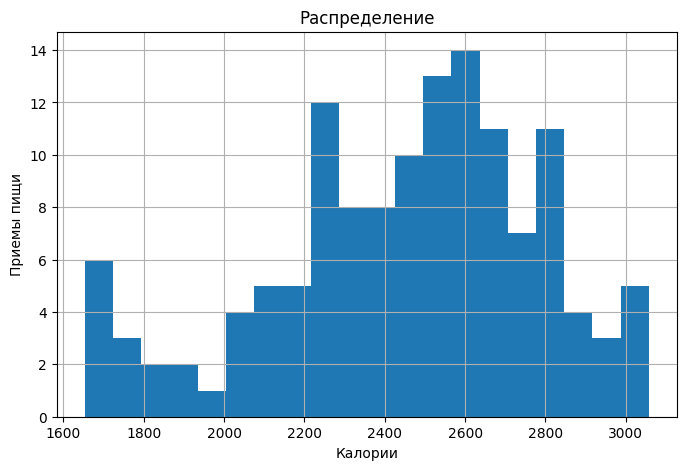

In [41]:
plt.figure(figsize=(8, 5))

plt.hist(df["Calories"], bins=20)

plt.title("Распределение")
plt.xlabel("Калории")
plt.ylabel("Приемы пищи")
plt.grid(True)

plt.show()



## Ячейка 7. TODO: scatter plot

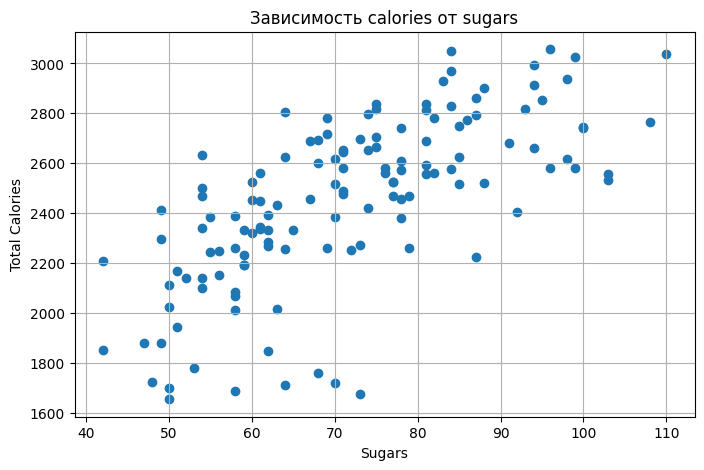

In [42]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Sugars"], df["Calories"])

plt.title("Зависимость calories от sugars")
plt.xlabel("Sugars")
plt.ylabel("Total Calories")
plt.grid(True)

plt.show()

assert len(df["Sugars"]) == len(df["Calories"])

## Ячейка 8. TODO: максимум и минимум

In [43]:
max_row = df.loc[df["Calories"].idxmax()]
min_row = df.loc[df["Calories"].idxmin()]

print("Максимальное количество калорий:")
print(max_row[["Date", "Calories"]])
print()
print("Минимальное количество калорий:")
print(min_row[["Date", "Calories"]])

assert max_row["Calories"] >= min_row["Calories"]

Максимальное количество калорий:
Date        25.01.27
Calories        3057
Name: 77, dtype: object

Минимальное количество калорий:
Date        25.06.16
Calories        1654
Name: 97, dtype: object


## Ячейка 9. TODO: TOP-10 и bar chart

,Date,Protein
75,25.01.13,206
71,24.12.16,205
81,25.02.24,205
107,25.08.25,202
70,24.12.09,200
69,24.12.02,199
108,25.09.01,198
110,25.09.15,195
78,25.02.03,194
76,25.01.20,194


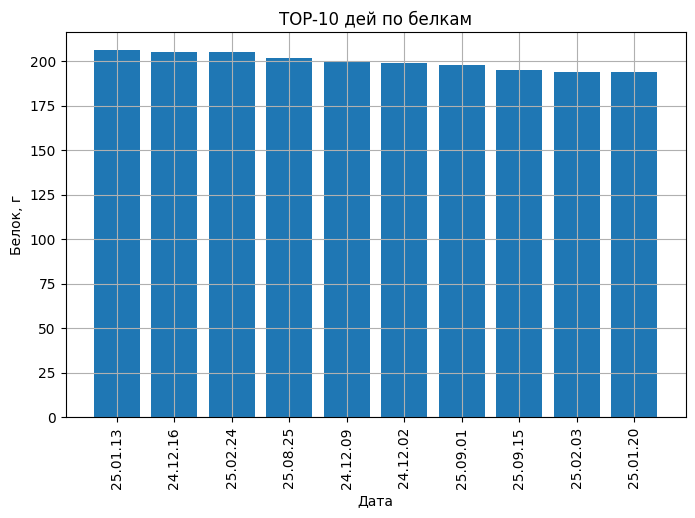

In [44]:
top10 = df.sort_values(by="Protein", ascending=False).head(10)

display(top10[["Date", "Protein"]])

plt.figure(figsize=(8, 5))

plt.bar(top10["Date"], top10["Protein"])

plt.title("TOP-10 дей по белкам")
plt.xlabel("Дата")
plt.ylabel("Белок, г")
plt.xticks(rotation=90)
plt.grid(True)

plt.show()

assert len(top10) == 10

## Ячейка 10. TODO: итоговый отчёт

In [45]:
summary = {
    "rows_count": len(df),
    "mean_calories": df["Calories"].mean(),
    "max_calories": df["Calories"].max(),
    "min_calories": df["Calories"].min(),
    "top_data": max_row["Date"],
}

for key, value in summary.items():
    print(key, ":", value)

conclusions = [
    "Датасет успешно загружен по ссылке.",
    "В таблице есть числовые признаки для математического анализа.",
    "Гистограмма показывает распределение общего экспорта.",
    "Scatter plot помогает изучить зависимость между признаками.",
    "TOP-10 позволяет найти лидеров по показателю.",
]

print()
print("Выводы:")
for item in conclusions:
    print("-", item)

assert summary["rows_count"] > 10
assert len(conclusions) == 5


rows_count : 134
mean_calories : 2450.283582089552
max_calories : 3057
min_calories : 1654
top_data : 25.01.27

Выводы:
- Датасет успешно загружен по ссылке.
- В таблице есть числовые признаки для математического анализа.
- Гистограмма показывает распределение общего экспорта.
- Scatter plot помогает изучить зависимость между признаками.
- TOP-10 позволяет найти лидеров по показателю.


# Что показать преподавателю

- загруженный датасет;
- структуру таблицы;
- статистику;
- гистограмму;
- scatter plot;
- максимум и минимум;
- TOP-10;
- выводы.